22/11/2019

The code here is close to Nielsen. Each activation is treated as a column vector, even the last one which for XOR is just a simple number and is encloded in a shape (1,1) column vector of just one row, i.e if activation value of output neuron is a, then it is computed as np.array([[a]]).

Can easily adapt code here for the MLP excercises and the Iris classification problem.
But you may need to use more than 2 hidden neurons and more than 1 output neuron.

In [38]:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
def sigm(z):
    return  1.0/(1.0 + np.exp(-z))

def sigm_deriv(z):
    a = sigm(z)
    return a*(1 - a)

In [40]:

class XOR_MLP:
    def __init__(self, input_size=2, hidden_size=2, output_size=1):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # XOR-specific inputs and outputs
        self.train_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
        self.train_outputs = np.array([[0], [1], [1], [0]])

        np.random.seed(23)

        # Initialize weights and biases
        self.w2 = np.random.randn(hidden_size, input_size)
        self.b2 = np.random.randn(hidden_size, 1)

        self.w3 = np.random.randn(output_size, hidden_size)
        self.b3 = np.random.randn(output_size, 1)

    def feedforward(self, xs):
        """Feedforward computation."""
        a2s = sigm(self.w2 @ xs + self.b2)
        a3s = sigm(self.w3 @ a2s + self.b3)
        return a3s

    def backprop(self, xs, ys):
        """Backpropagation for gradient calculation."""
        del_w2 = np.zeros(self.w2.shape, dtype=float)
        del_b2 = np.zeros(self.b2.shape, dtype=float)

        del_w3 = np.zeros(self.w3.shape, dtype=float)
        del_b3 = np.zeros(self.b3.shape, dtype=float)

        cost = 0.0
        for x, y in zip(xs, ys):
            a1 = x.reshape(self.input_size, 1)
            z2 = self.w2 @ a1 + self.b2
            a2 = sigm(z2)

            z3 = self.w3 @ a2 + self.b3
            a3 = sigm(z3)

            delta3 = (a3 - y) * sigm_deriv(z3)
            delta2 = sigm_deriv(z2) * (self.w3.T @ delta3)

            del_b3 += delta3
            del_w3 += delta3 @ a2.T

            del_b2 += delta2
            del_w2 += delta2 @ a1.T

            cost += ((a3 - y) ** 2).sum()

        n = len(ys)
        return del_b2 / n, del_w2 / n, del_b3 / n, del_w3 / n, cost / n

    def train(self, epochs, eta):
        """Training using gradient descent."""
        xs = self.train_inputs
        ys = self.train_outputs
        cost = np.zeros(epochs)

        for e in range(epochs):
            d_b2, d_w2, d_b3, d_w3, cost[e] = self.backprop(xs, ys)

            self.b2 -= eta * d_b2
            self.w2 -= eta * d_w2
            self.b3 -= eta * d_b3
            self.w3 -= eta * d_w3

        return cost
  

[[0.13441229 0.10816814 0.14522425 0.12453942]]
[[0.08467026 0.91859922 0.91853706 0.08963025]]


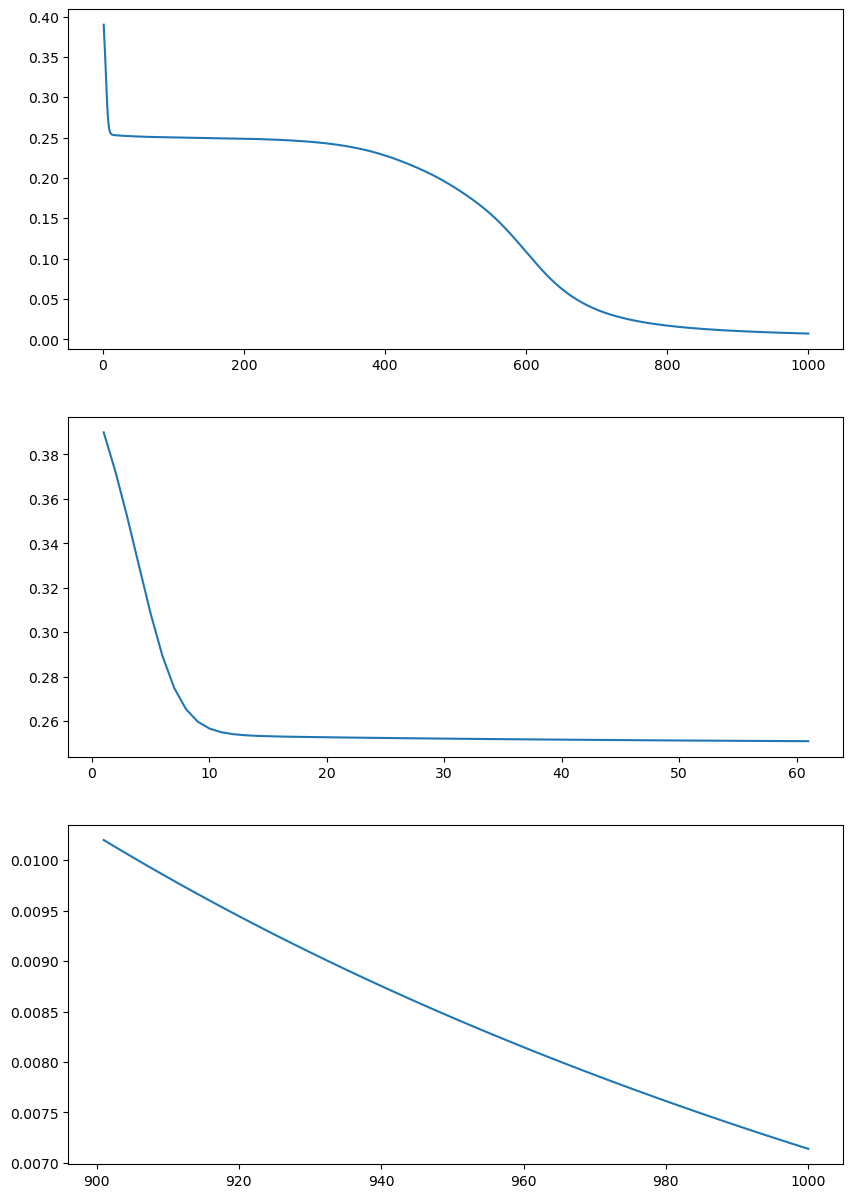

In [29]:
xor = XOR_MLP()
xs = xor.train_inputs.T

print(xor.feedforward(xs))

epochs = 1000
c = xor.train(epochs, 3.0)

print(xor.feedforward(xs))

x_axis = np.linspace(1, epochs, epochs, dtype=int)
fig, axs = plt.subplots(3,1,figsize=(10,15))
plt.subplot(3,1,1)
plt.plot(x_axis, c)
plt.subplot(3,1,2)
plt.plot(x_axis[:61], c[:61])
plt.subplot(3,1,3)
plt.plot(x_axis[900:], c[900:])





Exercise 1: copy and adapt the above XOR_MLP code so that it uses 3 neurons in the hidden layer. Train such a MLP and see if it learns faster than the previous one.

In [ ]:
# Exercise 1


In [175]:
# A more general purpose MLP with m input neurons, n hidden neurons and o output neurons
# You must complete this code yourself

import numpy as np
import pandas as pd

class MLP:
    def __init__(self, m, n, o):
        self.m = m  # Number of input neurons
        self.n = n  # Number of hidden neurons
        self.o = o  # Number of output neurons
        
        # Initialize weights and biases for the layers
        self.w2 = np.random.randn(self.m, self.n) * 0.01  # Weights between input and hidden layer
        self.b2 = np.zeros((1, self.n))  # Biases for hidden layer
        self.w3 = np.random.randn(self.n, self.o) * 0.01  # Weights between hidden and output layer
        self.b3 = np.zeros((1, self.o))  # Biases for output layer
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def sigmoid_derivative(self, z):
        return z * (1 - z)
    
    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        epsilon = 1e-12
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)) / m

    def mean_squared_error(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)
    
    def forward(self, X):
        # Forward propagation
        self.z2 = np.dot(X, self.w2) + self.b2
        self.a2 = self.sigmoid(self.z2)  # Hidden layer activation
        self.z3 = np.dot(self.a2, self.w3) + self.b3
        self.a3 = self.sigmoid(self.z3)  # Output layer activation
        return self.a3
    
    def backward(self, X, y, output, learning_rate, loss_function):
        m = y.shape[0]

        # Loss derivative
        if loss_function == 'mse':
            delta3 = (output - y) * self.sigmoid_derivative(output)
        elif loss_function == 'cross_entropy':
            delta3 = (output - y)
        else:
            raise ValueError("Invalid loss function")

        # Gradients for w3 and b3
        dW3 = np.dot(self.a2.T, delta3) / m
        db3 = np.sum(delta3, axis=0, keepdims=True) / m

        # Gradients for w2 and b2
        delta2 = np.dot(delta3, self.w3.T) * self.sigmoid_derivative(self.a2)
        dW2 = np.dot(X.T, delta2) / m
        db2 = np.sum(delta2, axis=0, keepdims=True) / m

        # Update weights and biases
        self.w3 -= learning_rate * dW3
        self.b3 -= learning_rate * db3
        self.w2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

    def train(self, X, y, epochs=3000, learning_rate=0.05, loss_function='mse'):
        losses = []
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)
            
            # Compute loss
            loss = self.cross_entropy_loss(y, output) if loss_function == 'cross_entropy' else self.mean_squared_error(y, output)
            losses.append(loss)
            
            # Backward pass
            self.backward(X, y, output, learning_rate, loss_function)
            
            # Print progress every 100 epochs
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss}")
        
        return losses

    def predict(self, X):
        output = self.forward(X)
        return np.round(output)


In [176]:
# Are the outputs of these correct?
p1 = MLP(3,4,2)
print('\n w2 = \n',p1.w2, '\n W3 = \n', p1.w3, '\n')

p2 = MLP(4,6,3)
print('\n w2 = \n', p2.w2, '\nW3 = \n', p2.w3, '\n')



 w2 = 
 [[-0.00696397  0.00624576  0.01536148  0.01121028]
 [ 0.00167108 -0.00723403 -0.00954651  0.00668368]
 [-0.0240227  -0.02435289  0.00800728 -0.00090375]] 
 W3 = 
 [[ 0.00580284  0.00901283]
 [-0.00846598 -0.00466071]
 [-0.01538256  0.01034094]
 [ 0.00415803  0.01030841]] 


 w2 = 
 [[ 0.00199588  0.00563896  0.01461878  0.00022864 -0.01070372  0.01421076]
 [-0.01111292 -0.00494687  0.00222643 -0.01307062 -0.01200725 -0.00884119]
 [-0.00129514  0.00335629  0.00147838 -0.00241798 -0.01082205  0.01408614]
 [ 0.01753897 -0.00162125  0.00497894  0.00928151  0.00217422  0.00447862]] 
W3 = 
 [[-0.00654556  0.00233994 -0.01534909]
 [-0.01557832  0.0027405  -0.01024682]
 [-0.0031461  -0.01081644 -0.01654188]
 [-0.0022712   0.00840265  0.01972645]
 [-0.00867588  0.01584614 -0.01264577]
 [-0.00585399 -0.01210869  0.01197974]] 



In [183]:

 # Problem 1: Generalize MLP class for any input, hidden, and output neurons parameterized
import numpy as np
import matplotlib.pyplot as plt

class MLP:
    def __init__(self, input_size, hidden_layers, output_size):
        self.input_size = input_size
        self.hidden_layers = hidden_layers  # List containing number of neurons in each hidden layer
        self.output_size = output_size

        # Initialize weights and biases lists
        self.weights = []
        self.biases = []
        for i, layer_size in enumerate(self.hidden_layers + [output_size]):
            if i == 0:
                # Input layer weights
                self.weights.append(np.random.randn(input_size, layer_size) * 0.01)
            else:
                # Hidden layer weights
                self.weights.append(np.random.randn(self.hidden_layers[i-1], layer_size) * 0.01)
            self.biases.append(np.zeros((1, layer_size)))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, z):
        return z * (1 - z)

    def forward(self, X):
        # Forward propagation
        self.activations = [X]
        for i, w in enumerate(self.weights):
            z = np.dot(self.activations[-1], w) + self.biases[i]
            a = self.sigmoid(z)
            self.activations.append(a)
        return self.activations[-1]

    def backward(self, X, y, output, learning_rate, loss_function):
        m = y.shape[0]

        # Loss derivative (delta)
        if loss_function == 'mse':
            delta = (output - y) * self.sigmoid_derivative(output)
        elif loss_function == 'cross_entropy':
            delta = (output - y)
        else:
            raise ValueError("Invalid loss function")

        deltas = [delta]
        for i in range(len(self.weights) - 1, 0, -1):
            delta = np.dot(deltas[0], self.weights[i].T) * self.sigmoid_derivative(self.activations[i])
            deltas.insert(0, delta)

        # Update weights and biases
        for i in range(len(self.weights)):
            dW = np.dot(self.activations[i].T, deltas[i]) / m
            db = np.sum(deltas[i], axis=0, keepdims=True) / m
            self.weights[i] -= learning_rate * dW
            self.biases[i] -= learning_rate * db

    def train(self, X, y, epochs=3000, learning_rate=0.05, loss_function='mse'):
        losses = []
        for epoch in range(epochs):
            output = self.forward(X)
            loss = self.cross_entropy_loss(y, output) if loss_function == 'cross_entropy' else self.mean_squared_error(y, output)
            losses.append(loss)
            self.backward(X, y, output, learning_rate, loss_function)
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss}")
        return losses

    def mean_squared_error(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)) / m

    def predict(self, X):
        output = self.forward(X)
        return np.round(output)

Epoch 0, Loss: 0.25000054858852055
Epoch 100, Loss: 0.25000000025840685
Epoch 200, Loss: 0.24999999999153086
Epoch 300, Loss: 0.24999999999139266
Epoch 400, Loss: 0.2499999999913842
Epoch 500, Loss: 0.24999999999137587
Epoch 600, Loss: 0.24999999999136752
Epoch 700, Loss: 0.24999999999135913
Epoch 800, Loss: 0.2499999999913508
Epoch 900, Loss: 0.24999999999134243
Epoch 1000, Loss: 0.24999999999133404
Epoch 1100, Loss: 0.24999999999132572
Epoch 1200, Loss: 0.2499999999913174
Epoch 1300, Loss: 0.249999999991309
Epoch 1400, Loss: 0.24999999999130063
Epoch 1500, Loss: 0.2499999999912923
Epoch 1600, Loss: 0.24999999999128392
Epoch 1700, Loss: 0.24999999999127556
Epoch 1800, Loss: 0.24999999999126724
Epoch 1900, Loss: 0.24999999999125888


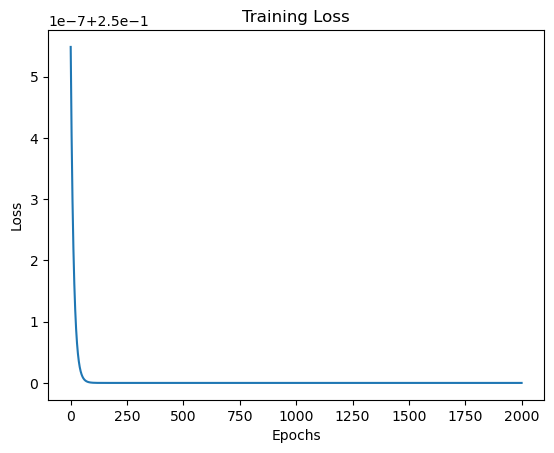

Predictions:
[[1.]
 [1.]
 [0.]
 [0.]]


In [178]:
# _Problem 1 Dataset
X = np.array([[0, 0, 1],
              [0, 1, 1],
              [1, 0, 1],
              [1, 1, 1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

# Create and train the MLP
mlp = MLP(input_size=3, hidden_layers=[4], output_size=1)
losses = mlp.train(X, y, epochs=2000, learning_rate=0.3)

# Plot losses
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Make predictions
predictions = mlp.predict(X)
print("Predictions:")
print(predictions)

Epoch 0, Loss: 0.2500018234047825
Epoch 100, Loss: 0.24999999999189892
Epoch 200, Loss: 0.24999999999187683
Epoch 300, Loss: 0.24999999999185463
Epoch 400, Loss: 0.24999999999183253
Epoch 500, Loss: 0.2499999999918104
Epoch 600, Loss: 0.2499999999917883
Epoch 700, Loss: 0.2499999999917661
Epoch 800, Loss: 0.249999999991744
Epoch 900, Loss: 0.24999999999172184
Epoch 1000, Loss: 0.24999999999169972
Epoch 1100, Loss: 0.2499999999916776
Epoch 1200, Loss: 0.2499999999916555
Epoch 1300, Loss: 0.24999999999163336
Epoch 1400, Loss: 0.2499999999916112


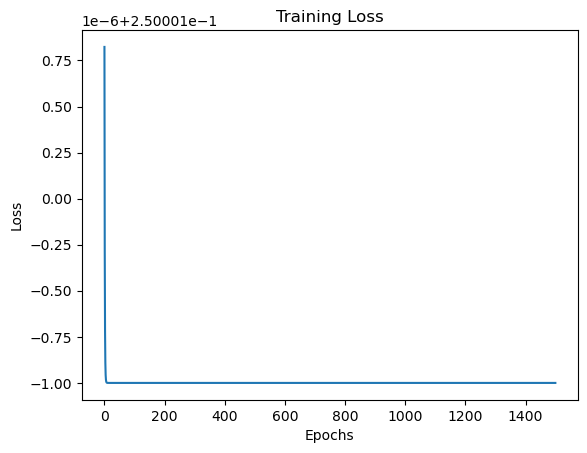

Predictions:
[[0.]
 [1.]
 [0.]
 [1.]]


In [184]:
# _Problem 1 Dataset
X = np.array([[0, 0, 1],
              [0, 1, 1],
              [1, 0, 1],
              [1, 1, 1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

# Create and train the MLP
mlp = MLP(input_size=3, hidden_layers=[4], output_size=1)
losses = mlp.train(X, y, epochs=1500, learning_rate=3.0)

# Plot losses
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Make predictions
predictions = mlp.predict(X)
print("Predictions:")
print(predictions)

Epoch 0, Loss: 1.3962781531143413
Epoch 100, Loss: 1.0893456804125372
Epoch 200, Loss: 1.0721351148711455
Epoch 300, Loss: 1.055915740184792
Epoch 400, Loss: 1.036770797427691
Epoch 500, Loss: 1.0146687891983792
Epoch 600, Loss: 0.9905440978129649
Epoch 700, Loss: 0.9658745546590068
Epoch 800, Loss: 0.9421079705947077
Epoch 900, Loss: 0.920217746996979
Epoch 1000, Loss: 0.9005890421341493
Epoch 1100, Loss: 0.8831533656902166
Epoch 1200, Loss: 0.8675922426916107
Epoch 1300, Loss: 0.8534998376760873
Epoch 1400, Loss: 0.8404798925636577
Epoch 1500, Loss: 0.8281920014981894
Epoch 1600, Loss: 0.8163679379575662
Epoch 1700, Loss: 0.8048127027834947
Epoch 1800, Loss: 0.7933983624640873
Epoch 1900, Loss: 0.7820544901831467
Epoch 2000, Loss: 0.7707569208184976
Epoch 2100, Loss: 0.7595157789888639
Epoch 2200, Loss: 0.7483636161080608
Epoch 2300, Loss: 0.7373445002215734
Epoch 2400, Loss: 0.7265047865322323
Epoch 2500, Loss: 0.715886016281652
Epoch 2600, Loss: 0.7055200355475338
Epoch 2700, Loss:

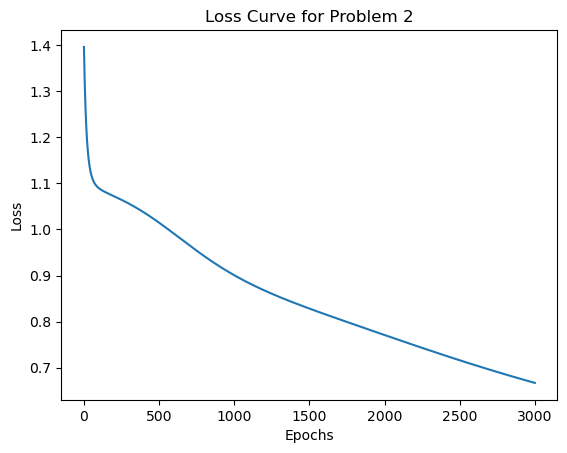

Prediction for example: [[1. 1.]]


In [85]:
# Problem 2: Neural Network with 3 inputs and 2 outputs
def problem_2_training():
    # Define dataset for Problem 2
    X = np.array([[1, 1, 0],
                  [1, -1, -1],
                  [-1, 1, 1],
                  [-1, -1, 1],
                  [0, 1, -1],
                  [0, -1, -1],
                  [1, 1, 1]])
    y = np.array([[1, 0],
                  [0, 1],
                  [1, 1],
                  [1, 0],
                  [1, 0],
                  [1, 1],
                  [1, 1]])

    # Create and train the MLP
    mlp_problem_2 = MLP(input_size=3, hidden_layers=[6], output_size=2)  # Use a list for hidden_layers
    problem_2_losses = mlp_problem_2.train(X, y, epochs=3000, learning_rate=0.05, loss_function='cross_entropy')

    # Plot loss
    plt.plot(problem_2_losses)
    plt.title('Loss Curve for Problem 2')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()

    # Predict example
    example = np.array([[1, 0, 1]])  # Example data
    prediction = mlp_problem_2.predict(example)
    print("Prediction for example:", prediction)

# Call Problem 2 training
problem_2_training()


Epoch 0, Loss: 2.079753165029378
Epoch 100, Loss: 1.8932477003999
Epoch 200, Loss: 1.8889577959336106
Epoch 300, Loss: 1.8789156446987931
Epoch 400, Loss: 1.8524054556467284
Epoch 500, Loss: 1.7881953239266148
Epoch 600, Loss: 1.667031827888381
Epoch 700, Loss: 1.5027639141910263
Epoch 800, Loss: 1.3414342399420618
Epoch 900, Loss: 1.2145754634401278
Epoch 1000, Loss: 1.117560285201568
Epoch 1100, Loss: 1.0329387577754463
Epoch 1200, Loss: 0.9467660090698639
Epoch 1300, Loss: 0.8535614236145681
Epoch 1400, Loss: 0.7560708628152482
Epoch 1500, Loss: 0.6602023921025367
Epoch 1600, Loss: 0.5710232474030726
Epoch 1700, Loss: 0.49163026695863865
Epoch 1800, Loss: 0.42316025221316905
Epoch 1900, Loss: 0.36533084769096585
Epoch 2000, Loss: 0.3170791411993815
Epoch 2100, Loss: 0.2770403917681513
Epoch 2200, Loss: 0.24383733185701106
Epoch 2300, Loss: 0.21622575129473165
Epoch 2400, Loss: 0.1931482147409169
Epoch 2500, Loss: 0.173737122050197
Epoch 2600, Loss: 0.15729456139313683
Epoch 2700, Lo

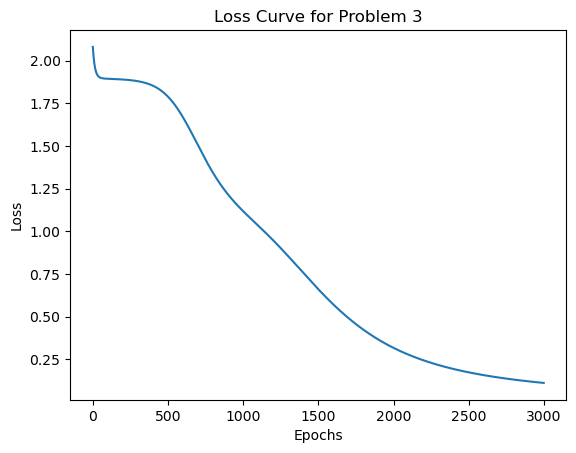

Prediction for the instance (Female): train


In [89]:
# Problem 3: Transportation Mode Choice
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def problem_3_training():
    # Define the dataset
    data = {
        'Gender': ['m', 'm', 'f', 'f', 'm', 'm', 'f', 'f', 'm', 'f'],
        'Car Ownership': [0, 1, 1, 0, 1, 0, 1, 1, 2, 2],
        'Travel Cost': ['cheap', 'cheap', 'cheap', 'cheap', 'cheap', 'standard', 'standard', 'expensive', 'expensive', 'expensive'],
        'Income Level': ['low', 'medium', 'medium', 'low', 'medium', 'medium', 'medium', 'high', 'medium', 'high'],
        'Mode': ['bus', 'bus', 'train', 'bus', 'bus', 'train', 'train', 'car', 'car', 'car']
    }
    df = pd.DataFrame(data)

    # Preprocess the data
    # One-hot encode categorical features
    categorical_features = pd.get_dummies(df[['Gender', 'Travel Cost', 'Income Level']])

    # Normalize numerical features manually
    numerical_features = df[['Car Ownership']].astype(float)
    numerical_mean = numerical_features.mean().to_numpy()
    numerical_std = numerical_features.std().to_numpy()
    numerical_scaled = (numerical_features.to_numpy() - numerical_mean) / numerical_std

    # Combine processed features
    X = np.hstack([numerical_scaled, categorical_features])

    # One-hot encode the target variable
    target_mapping = {mode: idx for idx, mode in enumerate(df['Mode'].unique())}
    y_encoded = df['Mode'].map(target_mapping).values
    y = np.eye(len(target_mapping))[y_encoded]

    # Train the MLP
    mlp_problem_3 = MLP(input_size=X.shape[1], hidden_layers=[8], output_size=y.shape[1])
    problem_3_losses = mlp_problem_3.train(X, y, epochs=3000, learning_rate=0.05, loss_function='cross_entropy')

    # Plot the loss curve
    plt.plot(problem_3_losses)
    plt.title('Loss Curve for Problem 3')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()

    # Predict for a new instance
    example_data = {
        'Gender': 'f',  # Female
        'Car Ownership': 0,
        'Travel Cost': 'expensive',
        'Income Level': 'medium'
    }

    # Manually encoded example
    example_categorical = pd.get_dummies(pd.DataFrame([example_data])).reindex(columns=categorical_features.columns, fill_value=0).values.astype(np.float64)
    example_numerical = (np.array([[example_data['Car Ownership']]], dtype=np.float64) - numerical_mean) / numerical_std
    example = np.hstack([example_numerical, example_categorical])

    prediction = mlp_problem_3.predict(example)
    mode_prediction = {v: k for k, v in target_mapping.items()}[np.argmax(prediction)]
    print("Prediction for the instance (Female):", mode_prediction)

# Call Problem 3 training
problem_3_training()



Epoch 0, Loss: 2.078686532864211
Epoch 100, Loss: 1.9063567091659317
Epoch 200, Loss: 1.8837912404734414
Epoch 300, Loss: 1.761907602412225
Epoch 400, Loss: 1.4419328213122298
Epoch 500, Loss: 1.1766235508184797
Epoch 600, Loss: 1.0526256750378522
Epoch 700, Loss: 0.9894859455561542
Epoch 800, Loss: 0.9485789833071118
Epoch 900, Loss: 0.9151492024494478
Epoch 1000, Loss: 0.8828442590262526
Epoch 1100, Loss: 0.8489780361059045
Epoch 1200, Loss: 0.8126797801436131
Epoch 1300, Loss: 0.7739157880924533
Epoch 1400, Loss: 0.7330638369052181
Epoch 1500, Loss: 0.6907824106728843
Epoch 1600, Loss: 0.6479006482619625
Epoch 1700, Loss: 0.6053072670848187
Epoch 1800, Loss: 0.5638658369269884
Epoch 1900, Loss: 0.524340395526755
Epoch 2000, Loss: 0.48733121008216906
Epoch 2100, Loss: 0.45323623030027815
Epoch 2200, Loss: 0.4222472110580347
Epoch 2300, Loss: 0.3943760157987544
Epoch 2400, Loss: 0.3694983221740547
Epoch 2500, Loss: 0.34740124438267506
Epoch 2600, Loss: 0.3278253110118417
Epoch 2700, L

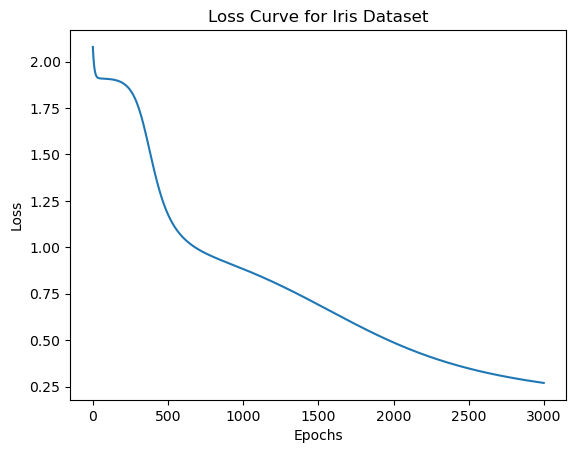

Prediction for example: Iris-setosa


In [103]:
# Problem 4: Load Iris dataset and train MLP
# Load Iris dataset
def load_iris_data():
    # Load the dataset from CSV
    df = pd.read_csv("iris_data.csv", header=None)
    X = df.iloc[:, :-1].values
    y = pd.get_dummies(df.iloc[:, -1]).values  # One-hot encoding of target
    class_names = df.iloc[:, -1].unique()  # Extract class names
    return X, y, class_names

# Iris dataset training
X, y, class_names = load_iris_data()
mlp_iris = MLP(input_size=X.shape[1], hidden_layers=[12], output_size=y.shape[1])
iris_losses = mlp_iris.train(X, y, epochs=3000, learning_rate=0.05, loss_function='cross_entropy')

# Plot loss for Iris dataset
plt.plot(iris_losses)
plt.title('Loss Curve for Iris Dataset')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Predict example for Iris dataset
# Predict example for Iris dataset
example = np.array([[5.1, 3.5, 1.4, 0.2]])  # Ensure input is 2D
output = mlp_iris.predict(example)  # Get raw predictions
predicted_class_index = np.argmax(output)  # Get the index of the highest probability
predicted_class_name = class_names[predicted_class_index]
print("Prediction for example:", predicted_class_name)


Epoch 0, Loss: 2.0719372617954717
Epoch 100, Loss: 0.8140398226299719
Epoch 200, Loss: 0.8572673177121624
Epoch 300, Loss: 0.40837934533440867
Epoch 400, Loss: 0.38897703837974396
Epoch 500, Loss: 0.3265646083820861
Epoch 600, Loss: 0.24574287147313129
Epoch 700, Loss: 0.20811452994849
Epoch 800, Loss: 0.18738642158385313
Epoch 900, Loss: 0.17403563166329414
Epoch 1000, Loss: 0.1644225584929092
Epoch 1100, Loss: 0.15707638261350504
Epoch 1200, Loss: 0.15143737788443887
Epoch 1300, Loss: 0.14722056606769732
Epoch 1400, Loss: 0.14391746139129158
Epoch 1500, Loss: 0.14098483169744205
Epoch 1600, Loss: 0.13819606034076864
Epoch 1700, Loss: 0.13552613848557896
Epoch 1800, Loss: 0.13299037229131452
Epoch 1900, Loss: 0.130597835230533
Epoch 2000, Loss: 0.12834881129028078
Epoch 2100, Loss: 0.12623852557668044
Epoch 2200, Loss: 0.12425985881886918
Epoch 2300, Loss: 0.12240480850242795
Epoch 2400, Loss: 0.12066520761133584
Epoch 2500, Loss: 0.11903304719784585
Epoch 2600, Loss: 0.11750059183480

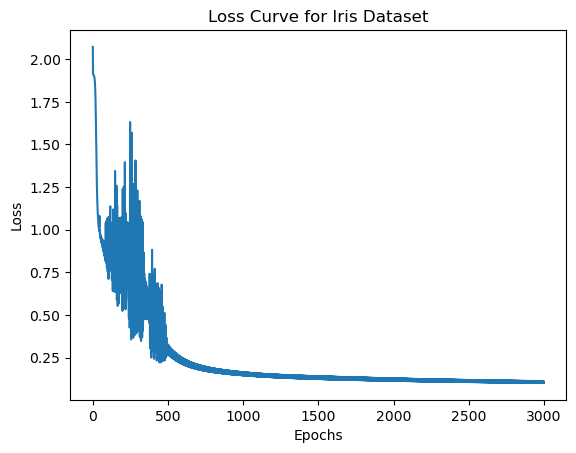

Prediction for example: Iris-setosa


In [179]:
# Problem 4: Load Iris dataset and train MLP

# Load Iris dataset
def load_iris_data():
    # Load the dataset from CSV
    df = pd.read_csv("iris_data.csv", header=None)
    X = df.iloc[:, :-1].values
    y = pd.get_dummies(df.iloc[:, -1]).values  # One-hot encoding of target
    class_names = df.iloc[:, -1].unique()  # Extract class names
    return X, y, class_names

# Iris dataset training
X, y, class_names = load_iris_data()
mlp_iris = MLP(input_size=X.shape[1], hidden_layers=[6], output_size=y.shape[1])
iris_losses = mlp_iris.train(X, y, epochs=3000, learning_rate=1.0, loss_function='cross_entropy')

# Plot loss for Iris dataset
plt.plot(iris_losses)
plt.title('Loss Curve for Iris Dataset')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Predict example for Iris dataset
# Predict example for Iris dataset
example = np.array([[5.1, 3.5, 1.4, 0.2]])  # Ensure input is 2D
output = mlp_iris.predict(example)  # Get raw predictions
predicted_class_index = np.argmax(output)  # Get the index of the highest probability
predicted_class_name = class_names[predicted_class_index]
print("Prediction for example:", predicted_class_name)




In [ ]:
#Emterprise data set found online training

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
def load_enterprise_data(file_path):
    # Load the CSV file into a pandas DataFrame
    df = pd.read_csv("annual-enterprise-survey-2023-financial-year-provisional-size-bands.csv")
    
    # Drop rows with missing values (if any)
    df = df.dropna()
    
    # Separate numerical and categorical columns
    numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
    categorical_cols = df.select_dtypes(include=['object']).columns
    
    # Normalize numerical columns
    numerical_data = (df[numerical_cols] - df[numerical_cols].mean()) / df[numerical_cols].std()
    
    # One-hot encode categorical columns
    categorical_data = pd.get_dummies(df[categorical_cols], drop_first=True)
    
    # Combine processed numerical and categorical data
    X = pd.concat([numerical_data, categorical_data], axis=1).values
    
    # Assume the last column is the target
    y = pd.get_dummies(df.iloc[:, -1]).values  # One-hot encoding for target column
    
    return X, y

# Train the MLP
def train_enterprise_mlp(file_path):
    X, y = load_enterprise_data(file_path)
    mlp_enterprise = MLP(input_size=X.shape[1], hidden_size=16, output_size=y.shape[1])
    losses = mlp_enterprise.train(X, y, epochs=3000, learning_rate=0.05, loss_function='cross_entropy')
    
    # Plot the loss curve
    plt.plot(losses)
    plt.title('Loss Curve for Enterprise Dataset')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()
    
    # Predict for an example (use the first row as an example)
    example = X[0].reshape(1, -1)  # Use the first row as input
    prediction = mlp_enterprise.predict(example)
    predicted_class = np.argmax(prediction)  # Get the index of the highest probability
    print("Prediction for example:", predicted_class)

# Call the function with your file path
file_path = "annual-enterprise-survey-2023-financial-year-provisional-size-bands.csv"
train_enterprise_mlp(file_path)


Starting training...
Training started for 3000 epochs.
X shape: (150, 4), y shape: (150, 3)
Epoch: 0
Epoch 0/3000, Loss: 2.1001
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19
Epoch: 20
Epoch: 21
Epoch: 22
Epoch: 23
Epoch: 24
Epoch: 25
Epoch: 26
Epoch: 27
Epoch: 28
Epoch: 29
Epoch: 30
Epoch: 31
Epoch: 32
Epoch: 33
Epoch: 34
Epoch: 35
Epoch: 36
Epoch: 37
Epoch: 38
Epoch: 39
Epoch: 40
Epoch: 41
Epoch: 42
Epoch: 43
Epoch: 44
Epoch: 45
Epoch: 46
Epoch: 47
Epoch: 48
Epoch: 49
Epoch: 50
Epoch: 51
Epoch: 52
Epoch: 53
Epoch: 54
Epoch: 55
Epoch: 56
Epoch: 57
Epoch: 58
Epoch: 59
Epoch: 60
Epoch: 61
Epoch: 62
Epoch: 63
Epoch: 64
Epoch: 65
Epoch: 66
Epoch: 67
Epoch: 68
Epoch: 69
Epoch: 70
Epoch: 71
Epoch: 72
Epoch: 73
Epoch: 74
Epoch: 75
Epoch: 76
Epoch: 77
Epoch: 78
Epoch: 79
Epoch: 80
Epoch: 81
Epoch: 82
Epoch: 83
Epoch: 84
Epoch: 85
Epoch: 86
Epoch: 87
Epoch: 88
E

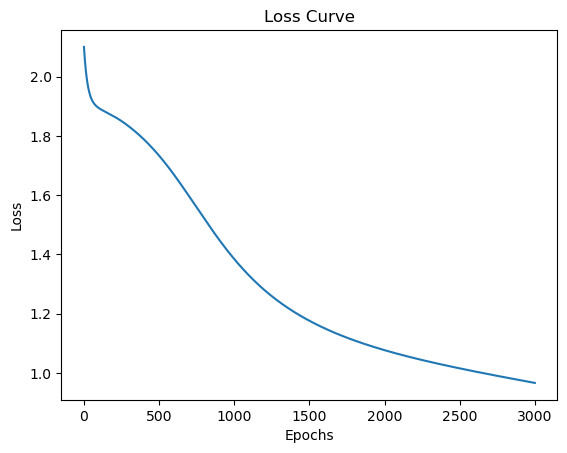

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess the dataset
def load_enterprise_data(file_path):
    df = pd.read_csv("annual-enterprise-survey-2023-financial-year-provisional-size-bands.csv")
    
    # Drop rows with missing values
    df = df.dropna()
    
    # Select relevant columns for training
    numerical_cols = ['value']
    categorical_cols = ['industry_code_ANZSIC', 'industry_name_ANZSIC', 'rme_size_grp']
    
    for col in numerical_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric
    df = df.dropna(subset=numerical_cols)  # Drop rows where conversion failed
    
    # Normalize numerical data
    numerical_data = (df[numerical_cols] - df[numerical_cols].mean()) / df[numerical_cols].std()
    
    # One-hot encode categorical columns
    categorical_data = pd.get_dummies(df[categorical_cols], drop_first=True)
    
    # Combine the data
    X = pd.concat([numerical_data, categorical_data], axis=1).values
    
    # Ensure that the data is float type
    X = X.astype(np.float32)  # Convert the entire dataset to float32
    
    # One-hot encode the target variable (industry code)
    y = pd.get_dummies(df['industry_code_ANZSIC']).values
    return X, y

class MLP:
    def __init__(self, input_size, hidden_layers, output_size):
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.output_size = output_size
        
        # Initialize weights and biases for each layer
        self.weights = []
        self.biases = []
        layer_sizes = [self.input_size] + self.hidden_layers + [self.output_size]
        
        for i in range(len(layer_sizes) - 1):
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.1)  # Xavier initialization
            self.biases.append(np.zeros((1, layer_sizes[i+1])))
            
    def forward(self, X):
        self.activations = [X]  # Store input as the first activation
        self.z_values = []
        
        for i in range(len(self.weights)):
            z = np.dot(self.activations[-1], self.weights[i]) + self.biases[i]
            self.z_values.append(z)
            a = self.sigmoid(z)
            self.activations.append(a)
            
        return self.activations[-1]
    
    def sigmoid(self, z):
        # Ensure z is of type float before applying np.exp
        if not np.issubdtype(z.dtype, np.floating):
            raise ValueError(f"Expected floating point type, got {z.dtype}")
        return 1 / (1 + np.exp(-z))
    
    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]  # Number of examples
        epsilon = 1e-12  # To avoid log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Clip predictions to avoid log(0)
        loss = -np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)) / m
        return loss
    
    def backward(self, X, y, learning_rate):
        m = X.shape[0]
        dA = self.activations[-1] - y  # Derivative of loss w.r.t the last activation
        
        for i in reversed(range(len(self.weights))):
            dZ = dA * self.sigmoid_derivative(self.z_values[i])
            dW = np.dot(self.activations[i].T, dZ) / m
            dB = np.sum(dZ, axis=0, keepdims=True) / m
            dA = np.dot(dZ, self.weights[i].T)
            
            # Update weights and biases
            self.weights[i] -= learning_rate * dW
            self.biases[i] -= learning_rate * dB
    
    def sigmoid_derivative(self, z):
        # Derivative of sigmoid function
        return self.sigmoid(z) * (1 - self.sigmoid(z))

    def train(self, X, y, epochs, learning_rate, loss_function='cross_entropy'):
        print(f"Training started for {epochs} epochs.")  # Confirm that training starts
        losses = []
        
        # Ensure that X and y are correct
        print(f"X shape: {X.shape}, y shape: {y.shape}")
        
        for epoch in range(epochs):
            print(f"Epoch: {epoch}")  # Track the current epoch
            
            try:
                # Forward pass
                output = self.forward(X)
                
                # Calculate loss
                if loss_function == 'cross_entropy':
                    loss = self.cross_entropy_loss(y, output)
                else:
                    loss = self.mean_squared_error(y, output)
                
                losses.append(loss)
                
                # Backward pass and weight update
                self.backward(X, y, learning_rate)
                
                # Log every 100th epoch
                if epoch % 100 == 0:
                    print(f"Epoch {epoch}/{epochs}, Loss: {loss:.4f}")
            
            except Exception as e:
                print(f"Error at epoch {epoch}: {e}")
                break
        
        return losses
    
    # def mean_squared_error(self, y_true, y_pred):
    #     return np.mean(np.square(y_true - y_pred))


# Training function
def train_enterprise_mlp():
    print("Starting training...")

    # Initialize the MLP model
    mlp_enterprise = MLP(input_size=X.shape[1], hidden_layers=[16], output_size=y.shape[1])
    
    # Train the model
    losses = mlp_enterprise.train(X, y, epochs=3000, learning_rate=0.05, loss_function='cross_entropy')
    
    # Plot the loss curve after training
    import matplotlib.pyplot as plt
    plt.plot(losses)
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()

# Make sure to call the training function
train_enterprise_mlp()


Starting training...
Training started for 3000 epochs.
X shape: (19751, 48), y shape: (19751, 20)
Epoch: 0
Epoch 0/3000, Loss: 0.2552
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19
Epoch: 20
Epoch: 21
Epoch: 22
Epoch: 23
Epoch: 24
Epoch: 25
Epoch: 26
Epoch: 27
Epoch: 28
Epoch: 29
Epoch: 30
Epoch: 31
Epoch: 32
Epoch: 33
Epoch: 34
Epoch: 35
Epoch: 36
Epoch: 37
Epoch: 38
Epoch: 39
Epoch: 40
Epoch: 41
Epoch: 42
Epoch: 43
Epoch: 44
Epoch: 45
Epoch: 46
Epoch: 47
Epoch: 48
Epoch: 49
Epoch: 50
Epoch: 51
Epoch: 52
Epoch: 53
Epoch: 54
Epoch: 55
Epoch: 56
Epoch: 57
Epoch: 58
Epoch: 59
Epoch: 60
Epoch: 61
Epoch: 62
Epoch: 63
Epoch: 64
Epoch: 65
Epoch: 66
Epoch: 67
Epoch: 68
Epoch: 69
Epoch: 70
Epoch: 71
Epoch: 72
Epoch: 73
Epoch: 74
Epoch: 75
Epoch: 76
Epoch: 77
Epoch: 78
Epoch: 79
Epoch: 80
Epoch: 81
Epoch: 82
Epoch: 83
Epoch: 84
Epoch: 85
Epoch: 86
Epoch: 87
Epoch

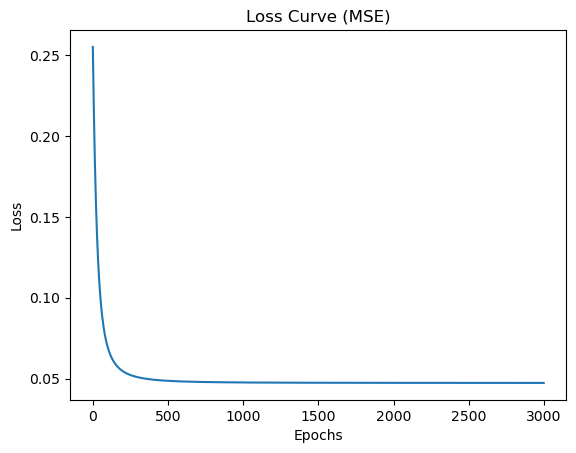

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess the dataset
def load_enterprise_data(file_path):
    df = pd.read_csv("annual-enterprise-survey-2023-financial-year-provisional-size-bands.csv")
    
    # Drop rows with missing values
    df = df.dropna()
    
    # Select relevant columns for training
    numerical_cols = ['value']
    categorical_cols = ['industry_code_ANZSIC', 'industry_name_ANZSIC', 'rme_size_grp']
    
    for col in numerical_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric
    df = df.dropna(subset=numerical_cols)  # Drop rows where conversion failed
    
    # Normalize numerical data
    numerical_data = (df[numerical_cols] - df[numerical_cols].mean()) / df[numerical_cols].std()
    
    # One-hot encode categorical columns
    categorical_data = pd.get_dummies(df[categorical_cols], drop_first=True)
    
    # Combine the data
    X = pd.concat([numerical_data, categorical_data], axis=1).values
    
    # Ensure that the data is float type
    X = X.astype(np.float32)  # Convert the entire dataset to float32
    
    # One-hot encode the target variable (industry code)
    y = pd.get_dummies(df['industry_code_ANZSIC']).values
    return X, y

class MLP:
    def __init__(self, input_size, hidden_layers, output_size):
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.output_size = output_size
        
        # Initialize weights and biases for each layer
        self.weights = []
        self.biases = []
        layer_sizes = [self.input_size] + self.hidden_layers + [self.output_size]
        
        for i in range(len(layer_sizes) - 1):
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.1)  # Xavier initialization
            self.biases.append(np.zeros((1, layer_sizes[i+1])))
            
    def forward(self, X):
        self.activations = [X]  # Store input as the first activation
        self.z_values = []
        
        for i in range(len(self.weights)):
            z = np.dot(self.activations[-1], self.weights[i]) + self.biases[i]
            self.z_values.append(z)
            a = self.sigmoid(z)
            self.activations.append(a)
            
        return self.activations[-1]
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def mean_squared_error(self, y_true, y_pred):
        # Mean Squared Error Loss
        return np.mean(np.square(y_true - y_pred))
    
    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]  # Number of examples
        epsilon = 1e-12  # To avoid log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Clip predictions to avoid log(0)
        loss = -np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)) / m
        return loss
    
    def backward(self, X, y, learning_rate):
        m = X.shape[0]
        dA = self.activations[-1] - y  # Derivative of loss w.r.t the last activation
        
        for i in reversed(range(len(self.weights))):
            dZ = dA * self.sigmoid_derivative(self.z_values[i])
            dW = np.dot(self.activations[i].T, dZ) / m
            dB = np.sum(dZ, axis=0, keepdims=True) / m
            dA = np.dot(dZ, self.weights[i].T)
            
            # Update weights and biases
            self.weights[i] -= learning_rate * dW
            self.biases[i] -= learning_rate * dB
    
    def sigmoid_derivative(self, z):
        return self.sigmoid(z) * (1 - self.sigmoid(z))

    def train(self, X, y, epochs, learning_rate, loss_function='mean_squared_error'):
        print(f"Training started for {epochs} epochs.")  # Confirm that training starts
        losses = []
        
        # Ensure that X and y are correct
        print(f"X shape: {X.shape}, y shape: {y.shape}")
        
        for epoch in range(epochs):
            print(f"Epoch: {epoch}")  # Track the current epoch
            
            try:
                # Forward pass
                output = self.forward(X)
                
                # Calculate loss
                if loss_function == 'cross_entropy':
                    loss = self.cross_entropy_loss(y, output)
                else:
                    loss = self.mean_squared_error(y, output)
                
                losses.append(loss)
                
                # Backward pass and weight update
                self.backward(X, y, learning_rate)
                
                # Log every 100th epoch
                if epoch % 100 == 0:
                    print(f"Epoch {epoch}/{epochs}, Loss: {loss:.4f}")
            
            except Exception as e:
                print(f"Error at epoch {epoch}: {e}")
                break
        
        return losses


# Training function
def train_enterprise_mlp():
    # Load data from CSV file
    X, y = load_enterprise_data('annual-enterprise-survey-2023-financial-year-provisional-size-bands.csv')
    
    print("Starting training...")

    # Initialize the MLP model
    mlp_enterprise = MLP(input_size=X.shape[1], hidden_layers=[16], output_size=y.shape[1])
    
    # Train the model using Mean Squared Error loss
    losses = mlp_enterprise.train(X, y, epochs=3000, learning_rate=0.05, loss_function='mean_squared_error')
    
    # Plot the loss curve after training
    plt.plot(losses)
    plt.title('Loss Curve (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()

# Call the training function
train_enterprise_mlp()


Starting training...
Training started for 3000 epochs.
X shape: (19751, 48), y shape: (19751, 20)
Epoch: 0
Epoch 0/3000, Loss: 0.6612
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19
Epoch: 20
Epoch: 21
Epoch: 22
Epoch: 23
Epoch: 24
Epoch: 25
Epoch: 26
Epoch: 27
Epoch: 28
Epoch: 29
Epoch: 30
Epoch: 31
Epoch: 32
Epoch: 33
Epoch: 34
Epoch: 35
Epoch: 36
Epoch: 37
Epoch: 38
Epoch: 39
Epoch: 40
Epoch: 41
Epoch: 42
Epoch: 43
Epoch: 44
Epoch: 45
Epoch: 46
Epoch: 47
Epoch: 48
Epoch: 49
Epoch: 50
Epoch: 51
Epoch: 52
Epoch: 53
Epoch: 54
Epoch: 55
Epoch: 56
Epoch: 57
Epoch: 58
Epoch: 59
Epoch: 60
Epoch: 61
Epoch: 62
Epoch: 63
Epoch: 64
Epoch: 65
Epoch: 66
Epoch: 67
Epoch: 68
Epoch: 69
Epoch: 70
Epoch: 71
Epoch: 72
Epoch: 73
Epoch: 74
Epoch: 75
Epoch: 76
Epoch: 77
Epoch: 78
Epoch: 79
Epoch: 80
Epoch: 81
Epoch: 82
Epoch: 83
Epoch: 84
Epoch: 85
Epoch: 86
Epoch: 87
Epoch

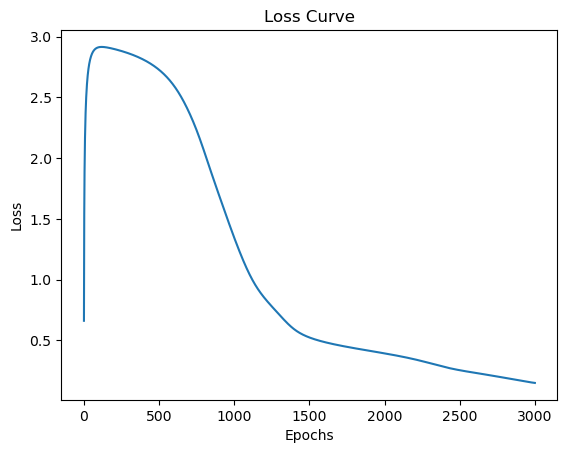

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess the dataset
def load_enterprise_data(file_path):
    df = pd.read_csv(file_path)
    
    # Drop rows with missing values
    df = df.dropna()
    
    # Select relevant columns for training
    numerical_cols = ['value']
    categorical_cols = ['industry_code_ANZSIC', 'industry_name_ANZSIC', 'rme_size_grp']
    
    for col in numerical_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric
    df = df.dropna(subset=numerical_cols)  # Drop rows where conversion failed
    
    # Normalize numerical data
    numerical_data = (df[numerical_cols] - df[numerical_cols].mean()) / df[numerical_cols].std()
    
    # One-hot encode categorical columns
    categorical_data = pd.get_dummies(df[categorical_cols], drop_first=True)
    
    # Combine the data
    X = pd.concat([numerical_data, categorical_data], axis=1).values
    
    # Ensure that the data is float type
    X = X.astype(np.float32)  # Convert the entire dataset to float32
    
    # One-hot encode the target variable (industry code)
    y = pd.get_dummies(df['industry_code_ANZSIC']).values
    return X, y


class MLP:
    def __init__(self, input_size, hidden_layers, output_size):
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.output_size = output_size
        
        # Initialize weights and biases for each layer
        self.weights = []
        self.biases = []
        layer_sizes = [self.input_size] + self.hidden_layers + [self.output_size]
        
        for i in range(len(layer_sizes) - 1):
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.1)  # Xavier initialization
            self.biases.append(np.zeros((1, layer_sizes[i+1])))
    
    def forward(self, X):
        self.activations = [X]  # Store input as the first activation
        self.z_values = []
        
        for i in range(len(self.weights)):
            z = np.dot(self.activations[-1], self.weights[i]) + self.biases[i]
            self.z_values.append(z)
            a = self.sigmoid(z)
            self.activations.append(a)
            
        return self.activations[-1]
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]  # Number of examples
        epsilon = 1e-12  # To avoid log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Clip predictions to avoid log(0)
        loss = -np.sum(y_true * np.log(y_pred)) / m
        return loss
    
    def backward(self, X, y, learning_rate):
        m = X.shape[0]
        dA = self.activations[-1] - y  # Derivative of loss w.r.t the last activation
        
        for i in reversed(range(len(self.weights))):
            dZ = dA * self.sigmoid_derivative(self.z_values[i])
            dW = np.dot(self.activations[i].T, dZ) / m
            dB = np.sum(dZ, axis=0, keepdims=True) / m
            dA = np.dot(dZ, self.weights[i].T)
            
            # Update weights and biases
            self.weights[i] -= learning_rate * dW
            self.biases[i] -= learning_rate * dB
    
    def sigmoid_derivative(self, z):
        return self.sigmoid(z) * (1 - self.sigmoid(z))

    def train(self, X, y, epochs, learning_rate, loss_function='cross_entropy'):
        print(f"Training started for {epochs} epochs.")  # Confirm that training starts
        losses = []
        
        # Ensure that X and y are correct
        print(f"X shape: {X.shape}, y shape: {y.shape}")
        
        for epoch in range(epochs):
            print(f"Epoch: {epoch}")  # Track the current epoch
            
            try:
                # Forward pass
                output = self.forward(X)
                
                # Calculate loss
                if loss_function == 'cross_entropy':
                    loss = self.cross_entropy_loss(y, output)
                
                losses.append(loss)
                
                # Backward pass and weight update
                self.backward(X, y, learning_rate)
                
                # Log every 100th epoch
                if epoch % 100 == 0:
                    print(f"Epoch {epoch}/{epochs}, Loss: {loss:.4f}")
            
            except Exception as e:
                print(f"Error at epoch {epoch}: {e}")
                break
        
        return losses


# Training function
def train_enterprise_mlp():
    print("Starting training...")

    # Load the dataset
    file_path = "annual-enterprise-survey-2023-financial-year-provisional-size-bands.csv"
    X, y = load_enterprise_data(file_path)

    # Initialize the MLP model
    mlp_enterprise = MLP(input_size=X.shape[1], hidden_layers=[12], output_size=y.shape[1])
    
    # Train the model
    losses = mlp_enterprise.train(X, y, epochs=3000, learning_rate=2.0, loss_function='cross_entropy')
    
    # Plot the loss curve after training
    plt.plot(losses)
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()

# Make sure to call the training function
train_enterprise_mlp()
